In [24]:
# Global imports
import biosteam as bst, thermosteam as tmo, biorefineries as bf, numpy as np, pandas as pd
from biorefineries import cellulosic
from biosteam import main_flowsheet as F, units
from atj_saf.atj_bst.etj_chemicals import create_chemicals

In [18]:
butanol = tmo.Chemical('FormicAcid')

In [25]:
chems = create_chemicals()

In [28]:
chems['Water'].Psat(T=273.15)

611.2104516176793

In [30]:
buradiene = tmo.Chemicals('Butadiene')

LookupError: chemical 'u' not recognized

In [31]:
import thermosteam as tmo
chemicals = tmo.Chemicals(['Water', 'Ethanol'], cache=True)
Gamma = tmo.equilibrium.DortmundActivityCoefficients(chemicals)
composition = [0.5, 0.5]
T = 350.
Gamma(composition, T)

array([1.475, 1.242])

In [29]:
chems

CompiledChemicals([Water, Ethanol, AceticAcid, Furfural, Glycerol, H2SO4, NH3, LacticAcid, SuccinicAcid, P4O10, Lime, HNO3, NH4OH, Denaturant, DAP, AmmoniumAcetate, AmmoniumSulfate, NaNO3, Oil, HMF, N2, O2, CH4, H2S, SO2, CO2, NO2, NO, CO, Glucose, Xylose, Sucrose, CaSO4, Mannose, Galactose, Arabinose, CellulaseNutrients, Extract, Acetate, Tar, Ash, NaOH, Lignin, SolubleLignin, GlucoseOligomer, GalactoseOligomer, MannoseOligomer, XyloseOligomer, ArabinoseOligomer, Z_mobilis, T_reesei, Biomass, Cellulose, Protein, Enzyme, Glucan, Xylan, Xylitol, Cellobiose, CSL, DenaturedEnzyme, Arabinan, Mannan, Galactan, WWTsludge, Cellulase, Ethylene, Butene, Hex-1-ene, Dec-1-ene, Octadec-1-ene, Butane, Hexane, Decane, Octadecane, Hydrogen, Syndol, Nickel_SiAl, CobaltMolybdenum, Coal])


In [19]:
butanol.show()

Chemical: FormicAcid (phase_ref='l')
[Names]  CAS: 64-18-6
         InChI: CH2O2/c2-1-3/h1H,(H,...
         InChI_key: BDAGIHXWWSANSR-U...
         common_name: formic acid
         iupac_name: ('methanoic aci...
         pubchemid: 284
         smiles: C(=O)O
         formula: CH2O2
[Groups] Dortmund: <1HCOOH>
         UNIFAC: <1HCOOH>
         PSRK: <1HCOOH>
         NIST: <Empty>
[Data]   MW: 46.025 g/mol
         Tm: 281.45 K
         Tb: 374.15 K
         Tt: 281.45 K
         Tc: 588 K
         Pt: 2360 Pa
         Pc: 5.81e+06 Pa
         Vc: 0.0001159 m^3/mol
         Hf: -4.25e+05 J/mol
         S0: 129 J/K/mol
         LHV: 2.1029e+05 J/mol
         HHV: 2.543e+05 J/mol
         Hfus: 12680 J/mol
         Sfus: None
         omega: 0.3222
         dipole: 1.41 Debye
         similarity_variable: 0.10864
         iscyclic_aliphatic: 0
         combustion: {'CO2': 1, 'O2'...


In [10]:
chems['Butanol'].MW

TypeError: string indices must be integers

Azeotrope at P = 101.3 kPa:
  T = 351.40 K (78.25 degC)
  x_ethanol = y_ethanol = 0.8939 mol/mol (water = 0.1061)
  w_ethanol = 0.9556 kg/kg (water = 0.0444)


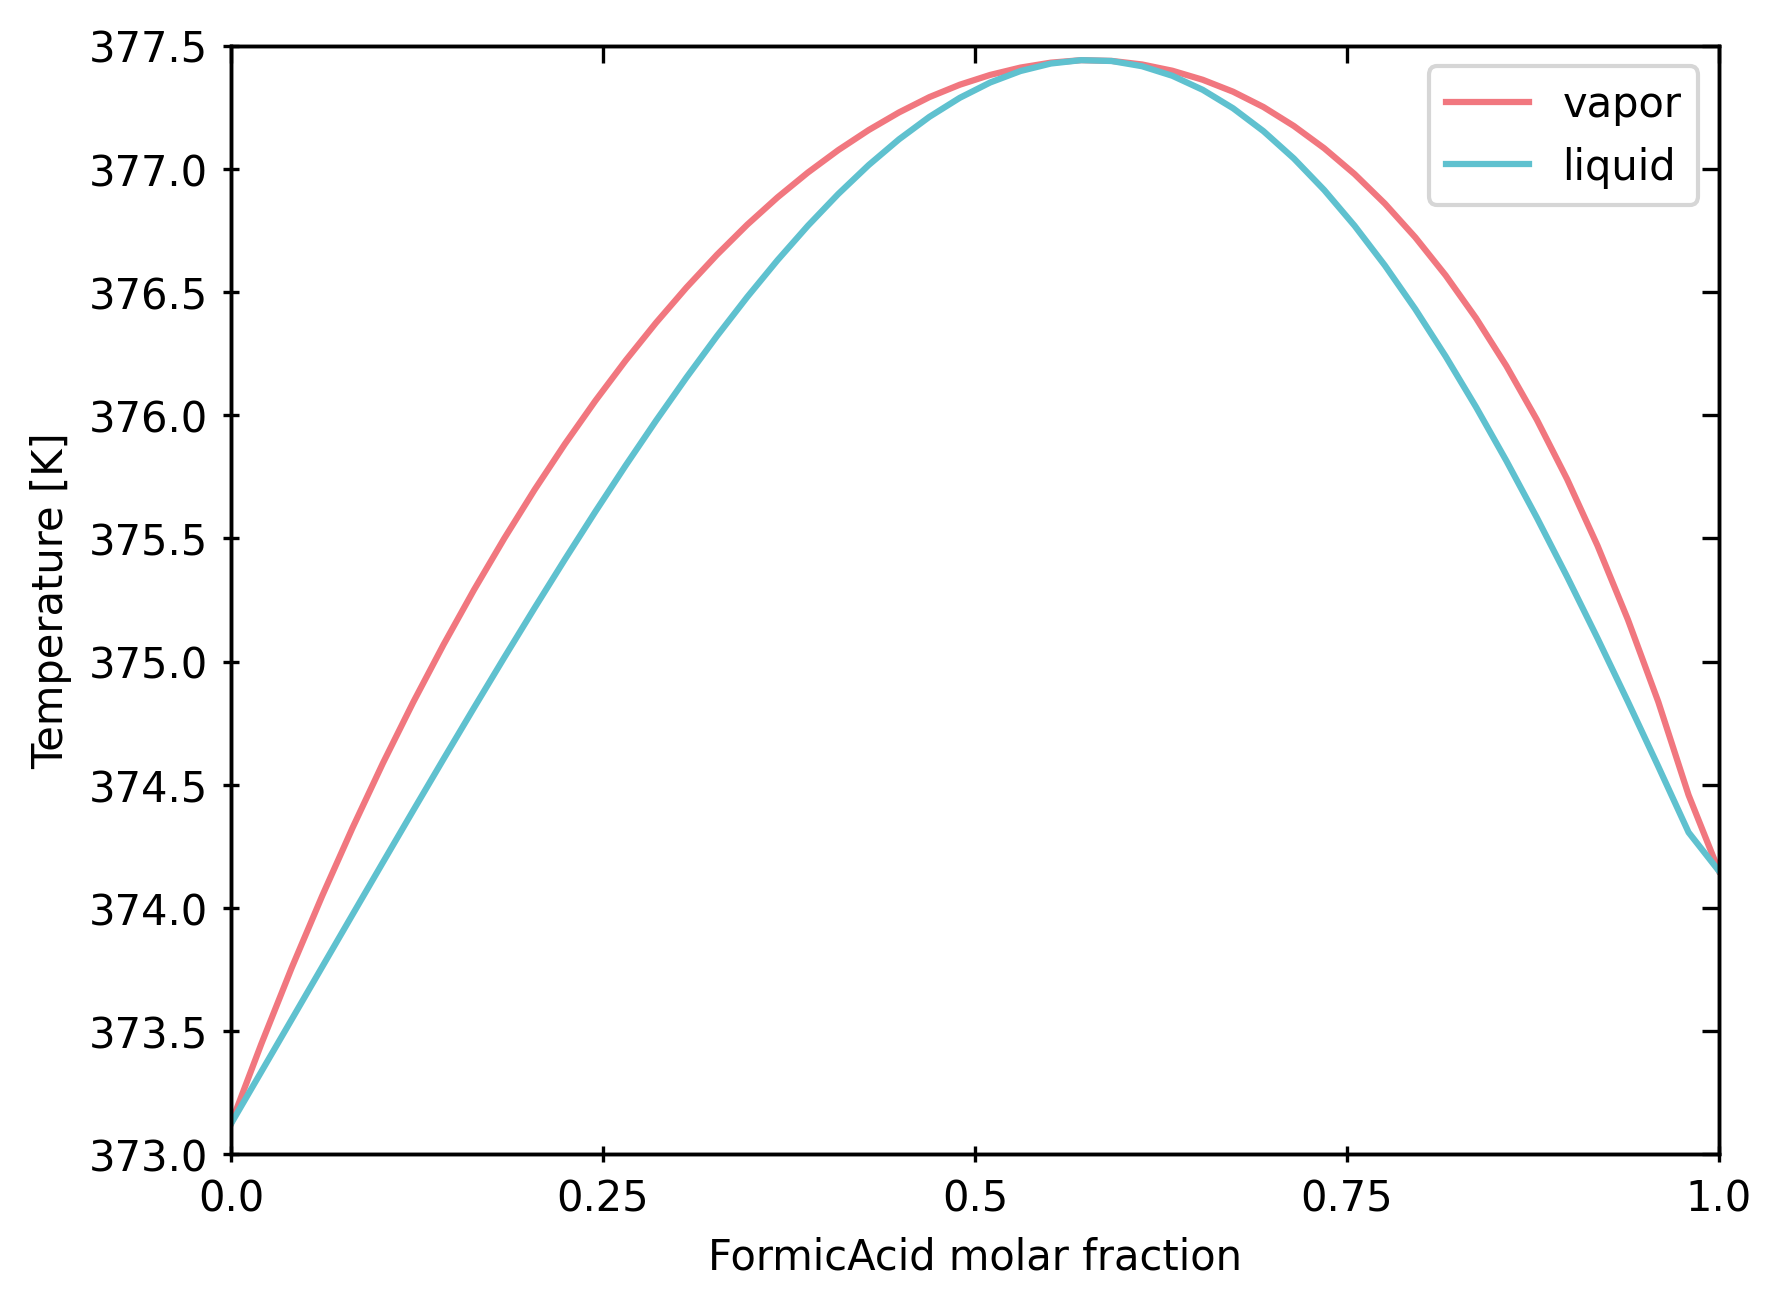

In [21]:
# Global imports
import biosteam as bst, thermosteam as tmo, biorefineries as bf, numpy as np, pandas as pd
from biorefineries import cellulosic
from biosteam import main_flowsheet as F, units
from scipy.optimize import brentq

bst.plot_vle_binary_phase_envelope(['FormicAcid', 'Water'], P=101325)

# --- Locate the azeotrope (x_ethanol = y_ethanol) at the same pressure ---
P = 101325
chemicals = ('Ethanol', 'Water')
thermo = tmo.Thermo(chemicals)
BP = tmo.BubblePoint(thermo.chemicals, thermo)

def y_minus_x(x_ethanol):
    bp = BP(np.array([x_ethanol, 1 - x_ethanol]), P=P)
    return bp.y[0] - x_ethanol

# scan for the sign change (skip the trivial pure-component endpoints)
xs = np.linspace(0.01, 0.99, 199)
diffs = [y_minus_x(x) for x in xs]
x_azeo = None
for x0, x1, d0, d1 in zip(xs[:-1], xs[1:], diffs[:-1], diffs[1:]):
    if d0 == 0:
        x_azeo = x0
        break
    if d0 * d1 < 0:
        x_azeo = brentq(y_minus_x, x0, x1)
        break

if x_azeo is None:
    print("No azeotrope found at this pressure (system may be zeotropic here).")
else:
    bp_azeo = BP(np.array([x_azeo, 1 - x_azeo]), P=P)
    mw_ethanol, mw_water = thermo.chemicals.Ethanol.MW, thermo.chemicals.Water.MW
    w_ethanol = (x_azeo * mw_ethanol) / (x_azeo * mw_ethanol + (1 - x_azeo) * mw_water)
    print(f"Azeotrope at P = {P/1000:.1f} kPa:")
    print(f"  T = {bp_azeo.T:.2f} K ({bp_azeo.T - 273.15:.2f} degC)")
    print(f"  x_ethanol = y_ethanol = {x_azeo:.4f} mol/mol (water = {1 - x_azeo:.4f})")
    print(f"  w_ethanol = {w_ethanol:.4f} kg/kg (water = {1 - w_ethanol:.4f})")


In [22]:
chems['Water']

TypeError: string indices must be integers

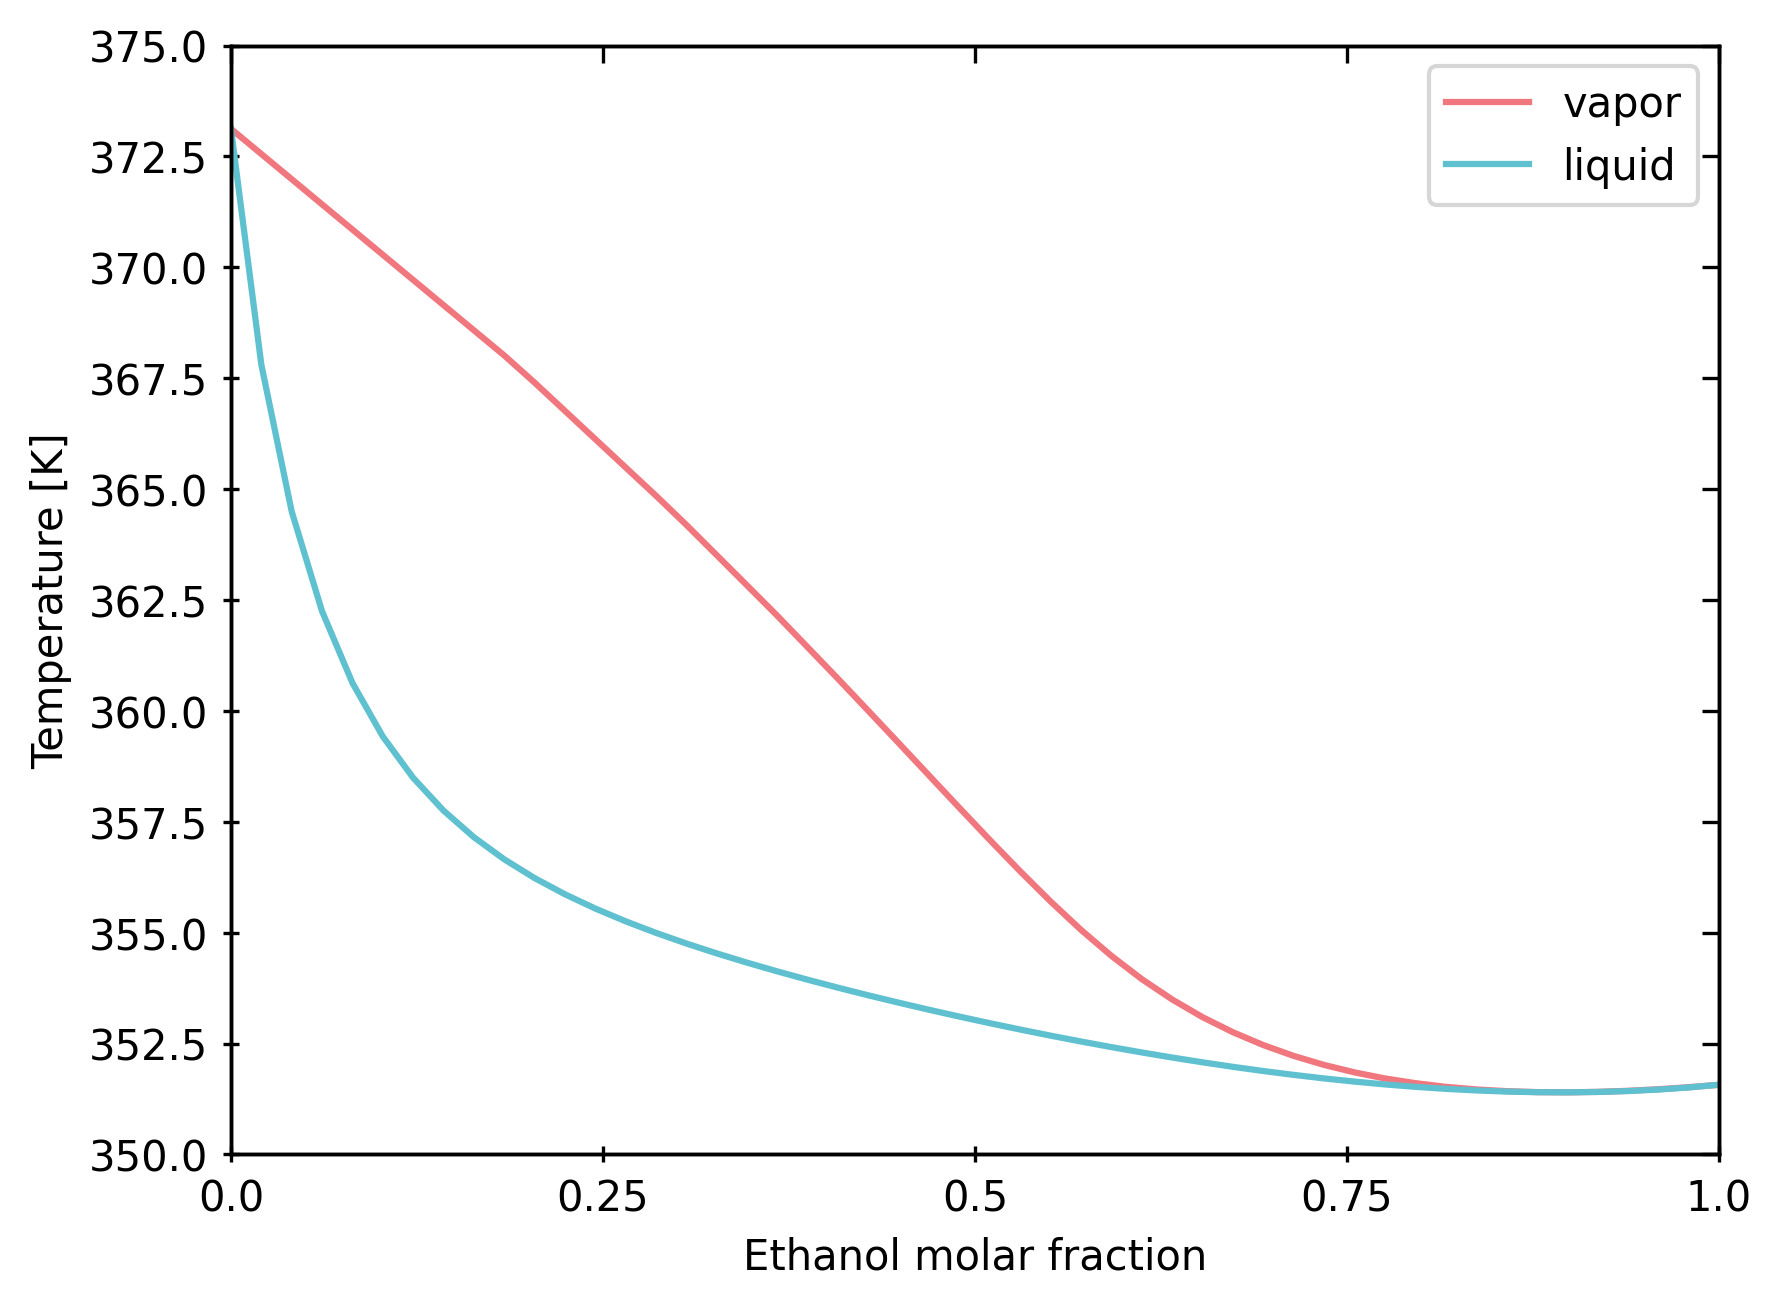

In [10]:
bst.plot_vle_binary_phase_envelope(['Ethanol', 'Water'], P=101325)

In [ ]:
break

In [1]:
import biosteam as bst

In [2]:
bst.settings.set_thermo(['Butane', 'Acetaldehyde'], cache=True)
feed = bst.Stream('feed', flow=(50, 50), T = 405, P = 101325)
outlet = feed.copy()
outlet.vle(T=270, P=101325)
outlet.show()
print('Vapor fraction:', outlet.vapor_fraction)
print('Gas phase mol:', outlet.imol['g'])
print('Liquid phase mol:', outlet.imol['l'])

MultiStream: 
phases: ('g', 'l'), T: 270 K, P: 101325 Pa
flow (kmol/hr): (l) Butane        50
                    Acetaldehyde  50
Vapor fraction: 0.0
Gas phase mol: [0. 0.]
Liquid phase mol: [50. 50.]


In [64]:
bst.settings.set_thermo(['Butane', 'Acetaldehyde'], cache=True)
feed = bst.Stream('feed', flow=(50, 50), T = 405, P = 101325)

heater = bst.units.HXutility(ins = feed, T = 415, rigorous = True)
heater.simulate()

In [73]:
# Calculate VLE at 300 K / 101325 Pa for heater.outs[0]
# bst.Stream has a built-in .vle equilibrium object (no need to build a
# MolarFlowIndexer by hand like the example above). Calling stream.vle(...)
# converts the stream to a two-phase MultiStream in place and flashes it,
# so operate on a copy if you don't want to mutate heater.outs[0].
outlet = heater.outs[0].copy()
outlet.vle(T=270, P=101325)
outlet.show()
print('Vapor fraction:', outlet.vapor_fraction)
print('Gas phase mol:', outlet.imol['g'])
print('Liquid phase mol:', outlet.imol['l'])

MultiStream: 
phases: ('g', 'l'), T: 270 K, P: 101325 Pa
flow (kmol/hr): (l) Butane        50
                    Acetaldehyde  50
Vapor fraction: 0.0
Gas phase mol: [0. 0.]
Liquid phase mol: [50. 50.]


In [58]:
heater-0

MultiStream: s5 from <HXutility: H5>
phases: ('g', 'l'), T: 415 K, P: 101325 Pa
flow (kmol/hr): (g) Benzene  50
                    Toluene  50


In [85]:
cooler = bst.units.HXutility(ins = heater-0, T = 273.15+35, rigorous = True)
cooler.simulate()

c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\IPython\core\interactiveshell.py:3579: RuntimeWarning: undocked inlet s8 from H13; s8 is now docked at H14
  exec(code_obj, self.user_global_ns, self.user_ns)


In [86]:
cooler.results()

Heat exchanger                                            Units       H14
Chilled water       Duty                                  kJ/hr -9.45e+05
                    Flow                                kmol/hr       626
                    Cost                                 USD/hr      4.73
Design              Area                                   ft^2      94.6
                    Overall heat transfer coefficient  kW/m^2/K       0.5
                    Log-mean temperature difference           K      61.3
                    Fouling correction factor                       0.975
                    Operating pressure                      psi      14.7
                    Total tube length                        ft        20
Purchase cost       Double pipe                             USD   5.1e+03
Total purchase cost                                         USD   5.1e+03
Utility cost                                             USD/hr      4.73

In [52]:
feed

Stream: feed to <HXutility: H3>
phase: 'l', T: 405 K, P: 101325 Pa
flow (kmol/hr): Benzene  50
                Toluene  50


In [51]:
heater.outs[0]
vle = equilibrium.VLE(heater.outs[0])

ValueError: imol chemicals must match thermo chemicals

In [48]:
from thermosteam import indexer, equilibrium, settings
settings.set_thermo(['Water', 'Ethanol', 'Methanol', 'Propanol'], cache=True)
imol = indexer.MolarFlowIndexer(
            l=[('Water', 304), ('Ethanol', 30)],
            g=[('Methanol', 40), ('Propanol', 1)])

MolarFlowIndexer (kmol/hr):
(g) Methanol  40
    Propanol  1
(l) Water     304
    Ethanol   30


In [45]:
BRUH

In [4]:
D1 = bst.units.BinaryDistillation('D1', ins=heater-0,
                        outs=('distillate', 'bottoms_product'),
                        LHK=('Benzene', 'Toluene'),
                        y_top = 0.999, x_bot = 0.001,
                        k=2)
D1.simulate()

In [5]:
D1.results()

Distillation Column                                        Units        D1
Electricity         Power                                     kW      1.69
                    Cost                                  USD/hr     0.132
Cooling water       Duty                                   kJ/hr -4.11e+06
                    Flow                                 kmol/hr  2.81e+03
                    Cost                                  USD/hr      1.37
Low pressure steam  Duty                                   kJ/hr  6.42e+06
                    Flow                                 kmol/hr       166
                    Cost                                  USD/hr      39.5
Design              Theoretical feed stage                              11
                    Theoretical stages                                  24
                    Minimum reflux                         Ratio      1.34
                    Reflux                                 Ratio      2.67
                    Actual stages                                       38
                    Height                                    ft      67.1
                    Diameter                                  ft      4.53
                    Wall thickness                            in     0.312
                    Weight                                    lb   1.3e+04
Purchase cost       Trays                                    USD  3.39e+04
                    Tower                                    USD  7.24e+04
                    Platform and ladders                     USD  2.59e+04
                    Condenser - Floating head                USD  2.57e+04
                    Reflux drum - Horizontal pressur...      USD  1.05e+04
                    Reflux drum - Platform and ladders       USD  3.02e+03
                    Pump - Pump                              USD  4.37e+03
                    Pump - Motor                             USD       418
                    Reboiler - Floating head                 USD   2.6e+04
Total purchase cost                                          USD  2.02e+05
Utility cost                                              USD/hr        41

In [6]:
D1.show(flow = 'kmol/hr', composition=True)

BinaryDistillation: D1
ins...
[0] s1  from  HXutility-H1
    phases: ('g', 'l'), T: 365 K, P: 101325 Pa
    composition (%): (l) Benzene  50
                         Toluene  50
                         -------  100 kmol/hr
outs...
[0] distillate  
    phase: 'g', T: 353.27 K, P: 101325 Pa
    composition (%): Benzene  99.9
                     Toluene  0.1
                     -------  50 kmol/hr
[1] bottoms_product  
    phase: 'l', T: 383.7 K, P: 101325 Pa
    composition (%): Benzene  0.1
                     Toluene  99.9
                     -------  50 kmol/hr


In [7]:
D2 = bst.units.MESHDistillation('D1', ins=heater-0,
                        outs=('distillate', 'bottoms_product'),
                        LHK=('Benzene', 'Toluene'),
                        reflux=2, boilup = 1.5, N_stages = 15, feed_stages = [7])
D2.simulate()

c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\IPython\core\interactiveshell.py:3579: RuntimeWarning: <BinaryDistillation: D1> has been replaced in registry
  exec(code_obj, self.user_global_ns, self.user_ns)
c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\thermosteam\_stream.py:398: RuntimeWarning: <Stream: distillate> has been replaced in registry
  self._register(ID)
c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\thermosteam\_stream.py:398: RuntimeWarning: <Stream: bottoms_product> has been replaced in registry
  self._register(ID)


KeyboardInterrupt: 

In [ ]:
D1.show(flow = 'kg/hr', composition=True)

BinaryDistillation: D1
ins...
[0] missing stream  
outs...
[0] distillate  
    phase: 'g', T: 353.27 K, P: 101325 Pa
    composition (%): Benzene  99.9
                     Toluene  0.118
                     -------  3.91e+03 kg/hr
[1] bottoms_product  
    phase: 'l', T: 383.7 K, P: 101325 Pa
    composition (%): Benzene  0.0848
                     Toluene  99.9
                     -------  4.61e+03 kg/hr


In [ ]:
feed

Stream: feed to <HXutility: H1>
phase: 'l', T: 365 K, P: 101325 Pa
flow (kmol/hr): Benzene  50
                Toluene  50


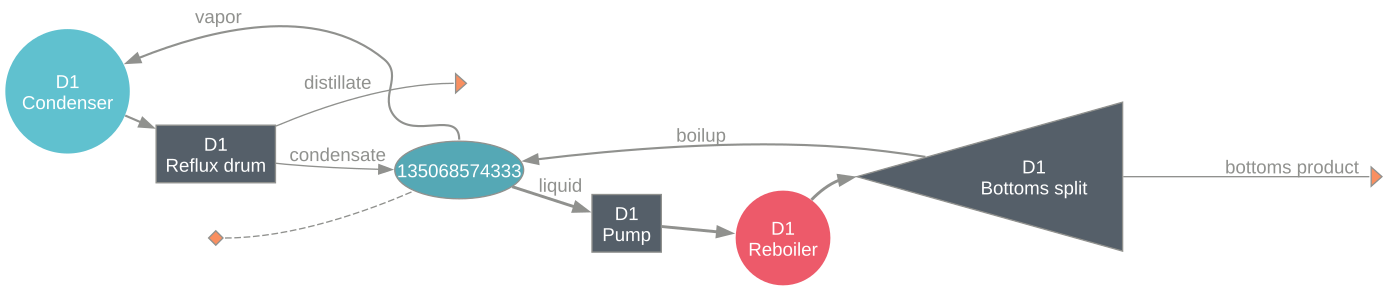

BinaryDistillation: D1
ins...
[0] -  
    phase: 'l', T: 298.15 K, P: 101325 Pa
    flow: 0
outs...
[0] distillate  
    phase: 'g', T: 353.27 K, P: 101325 Pa
    flow (kmol/hr): Benzene  50
                    Toluene  0.05
[1] bottoms_product  
    phase: 'l', T: 383.7 K, P: 101325 Pa
    flow (kmol/hr): Benzene  0.05
                    Toluene  50


In [ ]:
D1

In [ ]:
D1.results()

Distillation Column                                        Units        D1
Electricity         Power                                     kW      1.69
                    Cost                                  USD/hr     0.132
Cooling water       Duty                                   kJ/hr -4.11e+06
                    Flow                                 kmol/hr  2.81e+03
                    Cost                                  USD/hr      1.37
Low pressure steam  Duty                                   kJ/hr  6.42e+06
                    Flow                                 kmol/hr       166
                    Cost                                  USD/hr      39.5
Design              Theoretical feed stage                              11
                    Theoretical stages                                  24
                    Minimum reflux                         Ratio      1.34
                    Reflux                                 Ratio      2.67
                    Actual stages                                       38
                    Height                                    ft      67.1
                    Diameter                                  ft      4.53
                    Wall thickness                            in     0.312
                    Weight                                    lb   1.3e+04
Purchase cost       Trays                                    USD  3.39e+04
                    Tower                                    USD  7.24e+04
                    Platform and ladders                     USD  2.59e+04
                    Condenser - Floating head                USD  2.57e+04
                    Reflux drum - Horizontal pressur...      USD  1.05e+04
                    Reflux drum - Platform and ladders       USD  3.02e+03
                    Pump - Pump                              USD  4.37e+03
                    Pump - Motor                             USD       418
                    Reboiler - Floating head                 USD   2.6e+04
Total purchase cost                                          USD  2.02e+05
Utility cost                                              USD/hr        41

In [ ]:
import sys
from pathlib import Path

import matplotlib
matplotlib.use('Agg')

import biosteam as bst

# chopper's modules import each other with bare same-directory imports
# (e.g. `from sweep_separation import ...`), which only resolve when that
# directory is on sys.path -- true when running a script from inside it
# directly, but not when importing it as a package from here.
sys.path.insert(0, str(Path.cwd().parent / 'tools' / 'chopper'))

from optimizer import optimize_reflux_ratio
from separation_plots import (
    plot_purity_vs_reflux,
    plot_utility_cost_vs_reflux,
    plot_reflux_sweep,
)

bst.settings.set_thermo(['Water', 'Methanol', 'Glycerol'], cache=True)

feed = bst.Stream('feed', flow=(80, 100, 25), units='kmol/hr')
feed.T = feed.bubble_point_at_P().T

# k multipliers over minimum reflux, not absolute L/D values.
reflux_ratios_k = [1.5, 1.75, 2.0, 2.25, 2.5, 2.75, 3.0, 3.25, 3.5]

result = optimize_reflux_ratio(
    feed=feed,
    LHK=('Methanol', 'Water'),
    reflux_ratios_k=reflux_ratios_k,
    P=101325,
    spec='purity',
    target='top',
    purity_target=0.99,
    csv_path='demo_reflux_ratio_sweep.csv',
)

df = result['sweep_df']
print(df)

print(f"\nn_feasible: {result['n_feasible']}/{result['n_total']}")
print(result['message'])
if result['found']:
    print('\nBest design:')
    for k, v in result['best_design'].items():
        print(f'  {k}: {v}')

# 1. Call each plot function individually, saving each to its own file.
plot_purity_vs_reflux(df, save_path='demo_purity_vs_reflux.png', show=False)
plot_utility_cost_vs_reflux(df, save_path='demo_utility_cost_vs_reflux.png', show=False)

# 2. Or use the convenience wrapper to draw both at once.
plot_reflux_sweep(df, save_dir='.', show=False)

print('\nSaved: demo_purity_vs_reflux.png, demo_utility_cost_vs_reflux.png, '
      'purity_vs_reflux.png, utility_cost_vs_reflux.png')


c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\thermosteam\_stream.py:398: RuntimeWarning: <Stream: feed> has been replaced in registry
  self._register(ID)


   reflux_ratio_k  actual_reflux_ratio_LD  minimum_reflux_ratio_LD  theoretical_stages  purity  ...  cooling_cost_USD_hr  error annualized_capex_usd_per_yr  \
0             1.5                    1.03                    0.687                  16    0.99  ...                 1.22   None                    3.76e+04   
1            1.75                     1.2                    0.687                  14    0.99  ...                 1.42   None                    3.71e+04   
2               2                    1.37                    0.687                  13    0.99  ...                 1.63   None                    3.74e+04   
3            2.25                    1.54                    0.687                  12    0.99  ...                 1.83   None                    3.76e+04   
4             2.5                    1.72                    0.687                  11    0.99  ...                 2.03   None                    3.76e+04   
5            2.75                    1.89     

In [ ]:
from separation_trial import run_separation

In [ ]:
import biosteam as bst
from separation_trial import run_separation


# ---------------------------------------------------------
# 1. Set up the thermodynamic chemicals
# ---------------------------------------------------------

bst.settings.set_thermo(
    ['Water', 'Methanol', 'Glycerol'],
    cache=True
)


# ---------------------------------------------------------
# 2. Create the feed stream
# ---------------------------------------------------------

feed = bst.Stream(
    'feed',
    flow=(80, 100, 25),
    units='kmol/hr'
)

c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\thermosteam\_stream.py:398: RuntimeWarning: <Stream: feed> has been replaced in registry
  self._register(ID)


In [ ]:
result = run_separation(
    feed=feed,
    LHK=('Methanol', 'Water'),

    # Operating condition
    reflux_ratio=2.0,
    P=101325,

    # Separation specification
    spec='purity',
    target='top',

    # Distillation specifications
    y_top=0.99,
    x_bot=0.01,
)


TypeError: run_separation() missing 1 required positional argument: 'reflux_ratio_k'

In [ ]:
for R in [1.5, 2.0, 2.5, 3.0, 3.5]:

    result = run_separation(
        feed=feed,
        LHK=('Methanol', 'Water'),
        reflux_ratio=R,
        P=101325,
        spec='purity',
        target='top',
        y_top=0.99,
        x_bot=0.01,
    )

    print(
        R,
        result['purity']['achieved'],
        result['capex_usd'],
        result['utilities']['heating_cost_USD_per_hr'],
        result['utilities']['cooling_cost_USD_per_hr'],
        result['feasible'],
    )

1.5 0.99 211042.21137500647 54.34970564844269 1.2062093867131205 True
2.0 0.99 214962.36907292466 62.220559021843364 1.6082793299521048 True
2.5 0.99 216385.97282171948 71.19541409894285 2.010349299946949 True
3.0 0.99 225905.79389770923 80.17227001588417 2.4124192876304904 True
3.5 0.99 229548.44606890364 89.1507776165911 2.814489287618261 True


C:\Users\hwadg\AppData\Local\Temp\ipykernel_36588\2336271716.py:3: RuntimeWarning: <BinaryDistillation: D1> has been replaced in registry
  result = run_separation(
c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\thermosteam\_stream.py:398: RuntimeWarning: <Stream: distillate> has been replaced in registry
  self._register(ID)
c:\Users\hwadg\anaconda3\envs\pyfuel\lib\site-packages\thermosteam\_stream.py:398: RuntimeWarning: <Stream: bottoms> has been replaced in registry
  self._register(ID)


In [ ]:
D1.show(T='degC', P='atm', composition=True)

BinaryDistillation: D1
ins...
[0] feed  
    phase: 'l', T: 76.082 degC, P: 1 atm
    composition (%): Water     39
                     Methanol  48.8
                     Glycerol  12.2
                     --------  205 kmol/hr
outs...
[0] distillate  
    phase: 'g', T: 64.854 degC, P: 1 atm
    composition (%): Water     1
                     Methanol  99
                     --------  100 kmol/hr
[1] bottoms_product  
    phase: 'l', T: 100.02 degC, P: 1 atm
    composition (%): Water     75.4
                     Methanol  0.761
                     Glycerol  23.9
                     --------  105 kmol/hr
